Notebook to place a pattern on a FIB image

In [12]:
# for display
import napari
import matplotlib.pyplot as plt
import tifffile

# for the fibsem structures
from fibsem.structures import FibsemRectangleSettings, FibsemImage
from fibsem.patterning import FibsemMillingStage, get_milling_stages
from fibsem.microscope import FibsemMicroscope
from fibsem.patterns.ui import draw_milling_patterns

# for drawing patterns
from fibsem.ui.utils import _draw_patterns_in_napari
from fibsem import milling

# Set up test microscope
from fibsem import utils, acquire


In [41]:
# Set up test microscope
config_path = r"C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\fibsem\fibsem\config\microscope-configuration-demo2.yaml"
protocol_path = r"C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\scripts\spoof_microscope_protocol.yaml"


microscope, settings = utils.setup_session(config_path=config_path, protocol_path=protocol_path)

2024-12-18 16:10:23,016 — root — INFO — connect_to_microscope:5403 — Microscope client connected to DemoMicroscope with serial number 123456 and software version 0.1
2024-12-18 16:10:23,017 — root — INFO — setup_session:218 — Finished setup for session: openfibsem_2024-12-18-04-10-23PM


In [42]:
# "Acquire" images
eb_image, ib_image = acquire.take_reference_images(microscope, settings.image)

2024-12-18 16:10:24,628 — root — INFO — acquire_image:6383 — acquiring new ELECTRON image.
2024-12-18 16:10:24,629 — root — INFO — acquire_image:6384 — resolution:[1536, 1024], hfw:4e-05
2024-12-18 16:10:24,631 — root — INFO — acquire_image:6391 — SEM
2024-12-18 16:10:24,631 — root — INFO — load:141 — Loading C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\2024segmentation_testdata\SEM\01A_SEM_mill.tif as spoof image
2024-12-18 16:10:28,855 — root — INFO — acquire_image:6418 — img_data.type:<class 'numpy.ndarray'>
2024-12-18 16:10:28,856 — root — INFO — acquire_image:6419 — img_data.dtype:uint8, img_data.shape:(2048, 3072)
2024-12-18 16:10:28,857 — root — INFO — acquire_image:6423 — demo image has shape:(2048, 3072). Resizing to (np.int64(1024), np.int64(1536))
2024-12-18 16:10:29,034 — root — INFO — acquire_image:6427 — Resized, img_data.dtype:uint8, img_data.shape:(1024, 1536)
2024-12-18 16:10:29,035 — root — INFO — acquire_image:6441 — data_uint

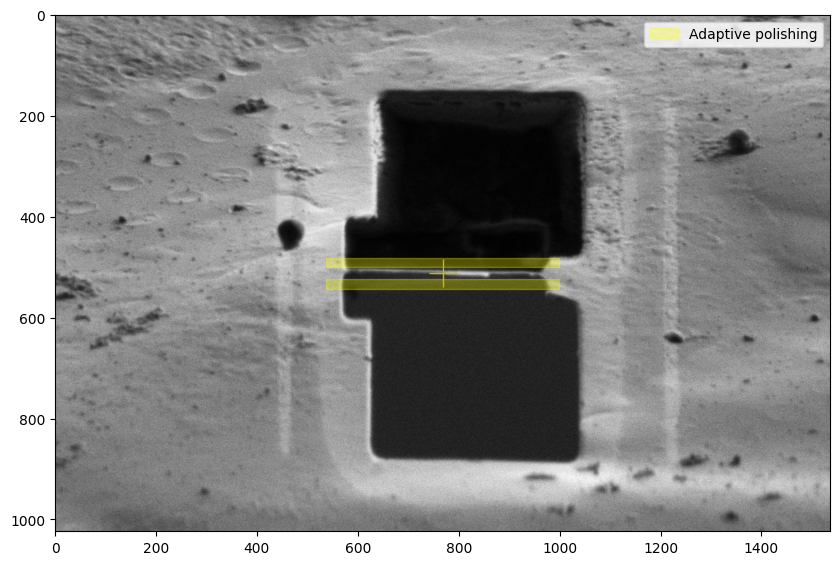

In [43]:
# Place pattern on FIB image
pattern = FibsemRectangleSettings(
    width=100,
    height=100,
    depth=40,
    centre_x=0,
    centre_y=0,
    time=30,
)
stages = get_milling_stages("lamella", settings.protocol["milling"])
fig = draw_milling_patterns(ib_image, stages)